# 1. Data Collecting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('https://drive.google.com/uc?id=1XZbZ5Z7MBXYaR3UO1HbQ4ncPi4R3HsyF')
df.head()

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [2]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df.describe()

Shape: (10000, 6)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  str    
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 468.9 KB

Missing values:
name        0
diameter    0
weight      0
red         0
green       0
blue        0
dtype: int64

Descriptive statistics:


,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


# 2. Exploratory Data Analysis (EDA)

Class distribution:
name
orange        5000
grapefruit    5000
Name: count, dtype: int64



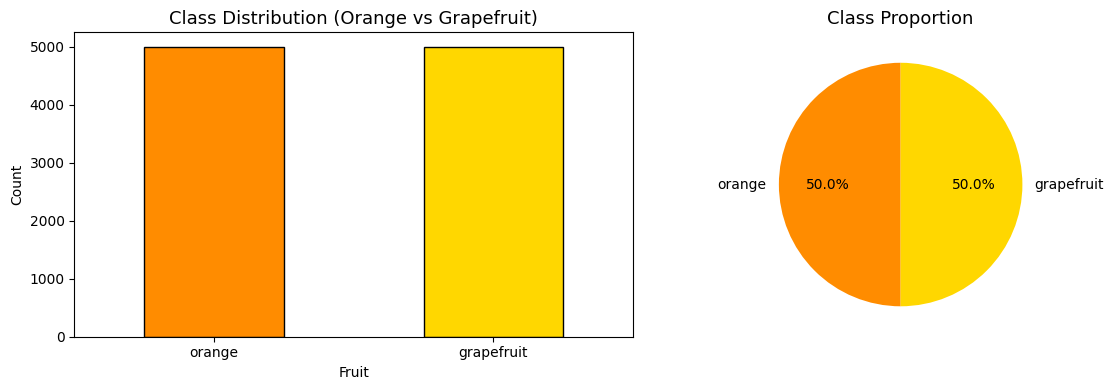

In [3]:
# Class distribution
print("Class distribution:")
print(df['name'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['name'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF8C00', '#FFD700'], edgecolor='black')
axes[0].set_title('Class Distribution (Orange vs Grapefruit)', fontsize=13)
axes[0].set_xlabel('Fruit')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['name'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                colors=['#FF8C00', '#FFD700'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

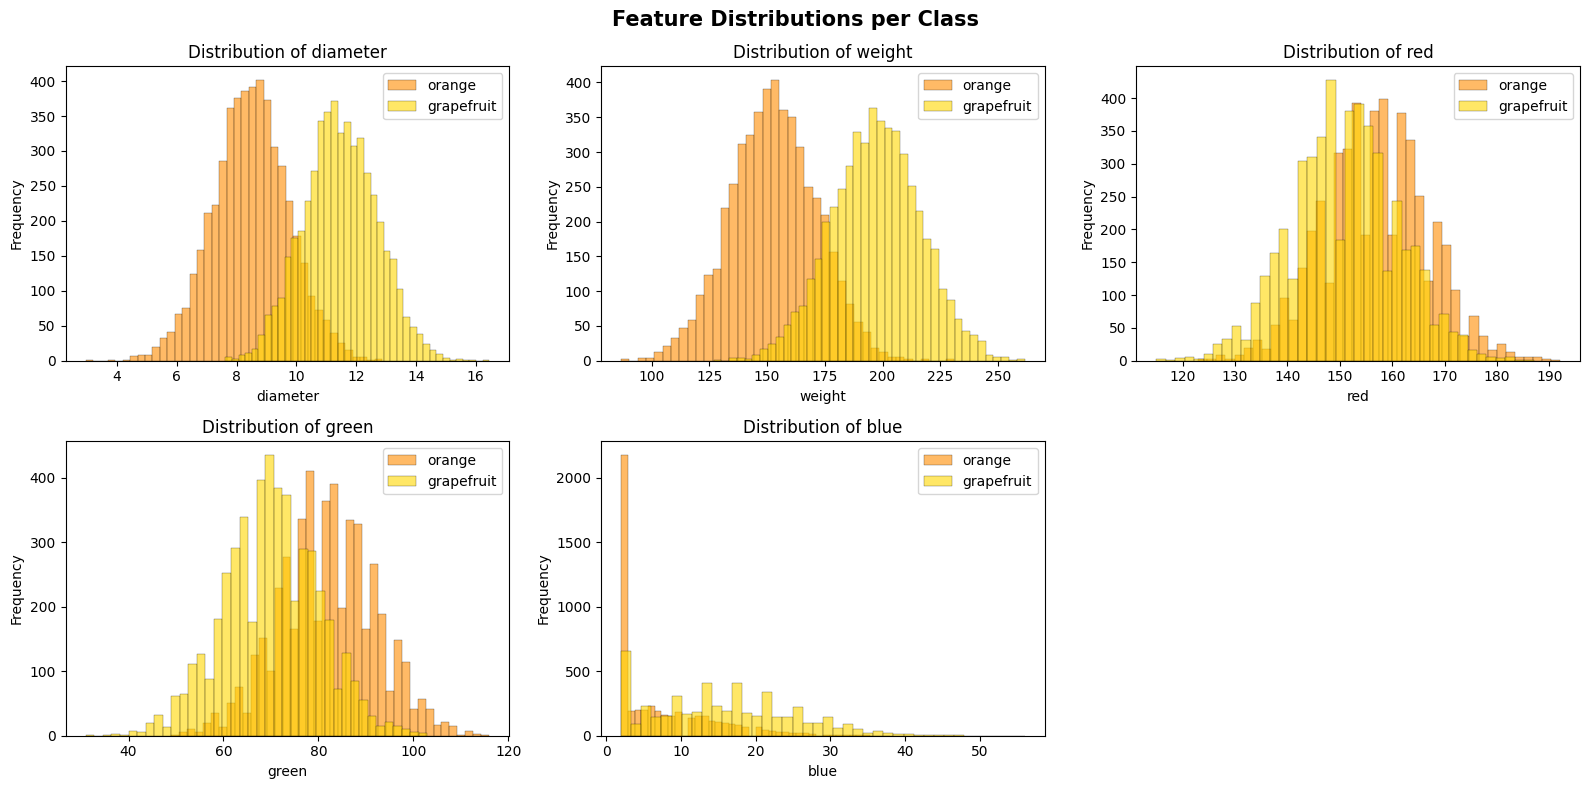

In [4]:
# Feature distribution per class
features = ['diameter', 'weight', 'red', 'green', 'blue']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = {'orange': '#FF8C00', 'grapefruit': '#FFD700'}

for i, feat in enumerate(features):
    for label in df['name'].unique():
        subset = df[df['name'] == label][feat]
        axes[i].hist(subset, bins=40, alpha=0.6, label=label, color=colors[label], edgecolor='black', linewidth=0.3)
    axes[i].set_title(f'Distribution of {feat}', fontsize=12)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

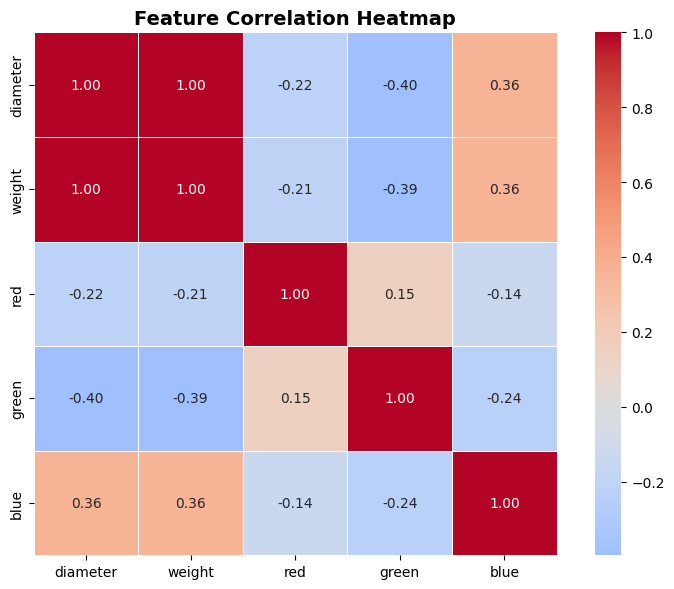

In [5]:
# Feature correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

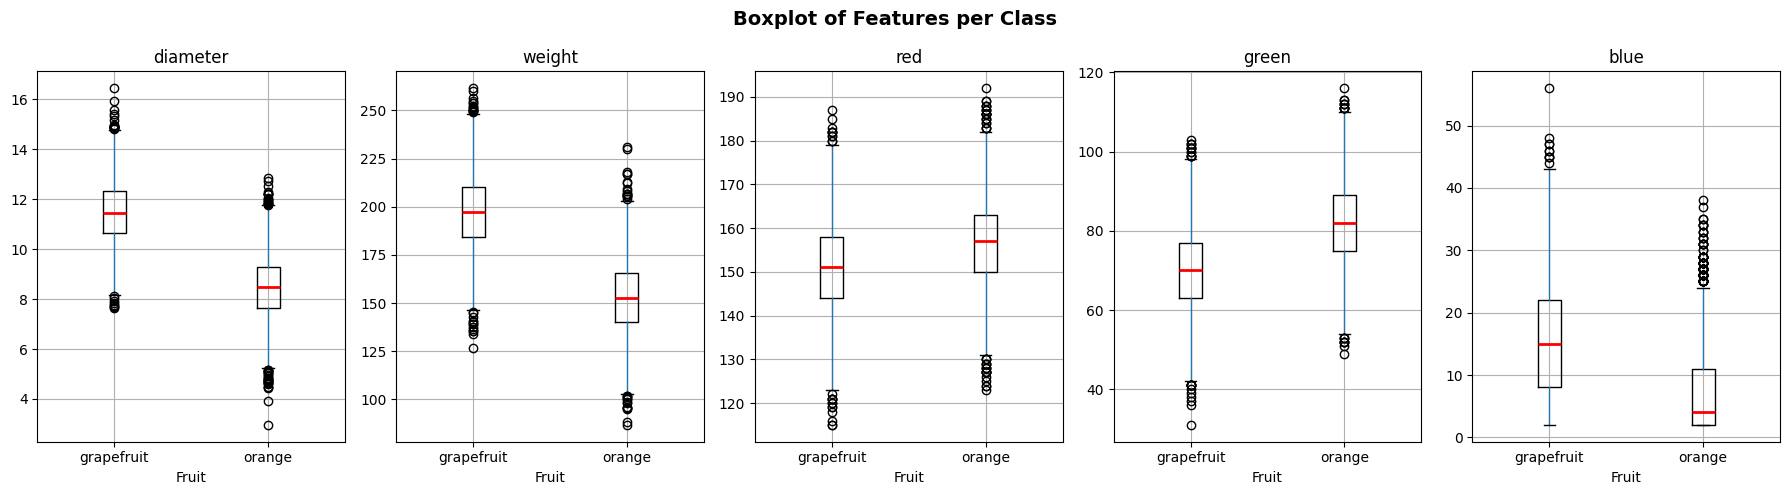

In [6]:
# Boxplot to check outliers and class separation
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, feat in enumerate(features):
    df.boxplot(column=feat, by='name', ax=axes[i],
               boxprops=dict(color='black'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('Fruit')

plt.suptitle('Boxplot of Features per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Label encoding
label_encoder = preprocessing.LabelEncoder()
df['label'] = label_encoder.fit_transform(df['name'])
print("Class mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print(df[['name', 'label']].head())

Class mapping: {'grapefruit': np.int64(0), 'orange': np.int64(1)}
     name  label
0  orange      1
1  orange      1
2  orange      1
3  orange      1
4  orange      1


In [8]:
# Separate features and target
X = df[['diameter', 'weight', 'red', 'green', 'blue']].values
y = df['label'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 5)
y shape: (10000,)


In [9]:
# Split FIRST, then scale — prevents data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train class distribution: {np.bincount(y_train.astype(int))}")
print(f"Test class distribution:  {np.bincount(y_test.astype(int))}")

Train size: 7000 | Test size: 3000
Train class distribution: [3500 3500]
Test class distribution:  [1500 1500]


In [10]:
# Scaling — fit on train only, transform on both train & test
min_max_scaler = preprocessing.MinMaxScaler()
X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled = min_max_scaler.transform(X_test)  # transform only, no fit!

print("X_train_scaled sample:")
print(X_train_scaled[:3])

X_train_scaled sample:
[[0.3795404  0.34374821 0.40540541 0.43529412 0.        ]
 [0.62861379 0.63164521 0.44594595 0.35294118 0.17391304]
 [0.64640474 0.65321888 0.43243243 0.64705882 0.        ]]


# 3. Preprocessing

In [11]:
# (scaling moved above — this cell is no longer used)
pass

In [12]:
# (train_test_split already done above with correct ordering)
pass

In [14]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

tf.random.set_seed(42)

model = Sequential([
    Input(shape=(5,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8116 - loss: 0.4755 - val_accuracy: 0.9336 - val_loss: 0.2202
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9130 - loss: 0.2171 - val_accuracy: 0.9321 - val_loss: 0.1776
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9184 - loss: 0.2071 - val_accuracy: 0.9329 - val_loss: 0.1745
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9205 - loss: 0.2001 - val_accuracy: 0.9336 - val_loss: 0.1704
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9212 - loss: 0.2012 - val_accuracy: 0.9321 - val_loss: 0.1686
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9229 - loss: 0.2024 - val_accuracy: 0.9329 - val_loss: 0.1702
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9221 - loss: 0.1998 - val_accuracy: 0.9307 - val_loss: 0.1694
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9241 - loss: 0.1989 - val_accu

# 4. Training History & Evaluasi

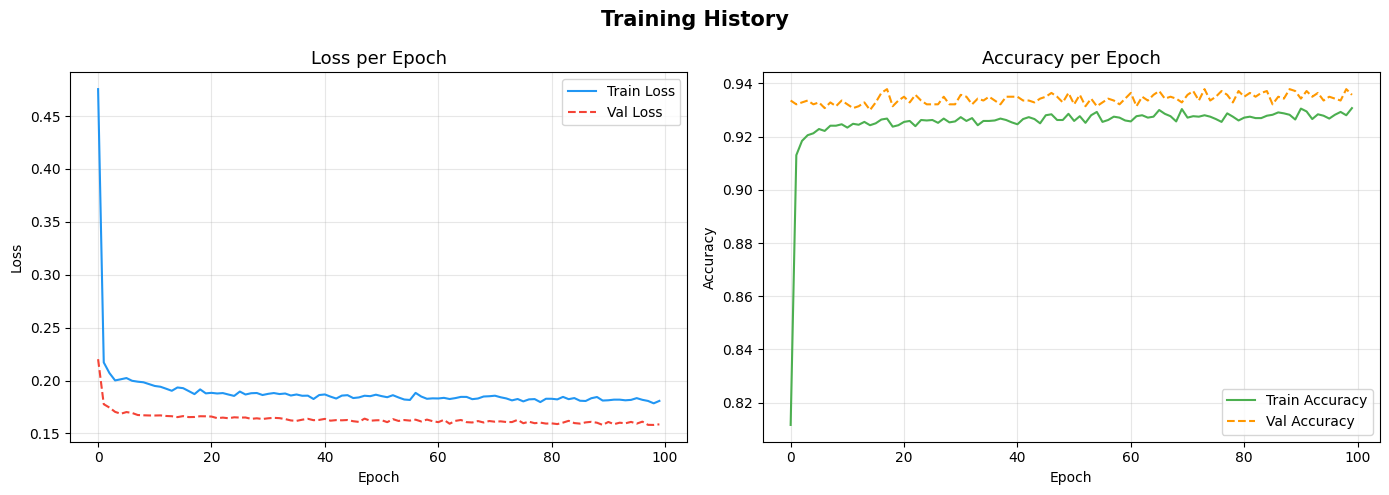

In [17]:
# Plot training vs validation loss & accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#F44336', linestyle='--')
axes[0].set_title('Loss per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#4CAF50')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#FF9800', linestyle='--')
axes[1].set_title('Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Evaluate on test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Loss    : 0.1728
Test Accuracy: 0.9293 (92.93%)


In [19]:
# Classification Report
y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.93      0.93      0.93      1500
      orange       0.93      0.93      0.93      1500

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



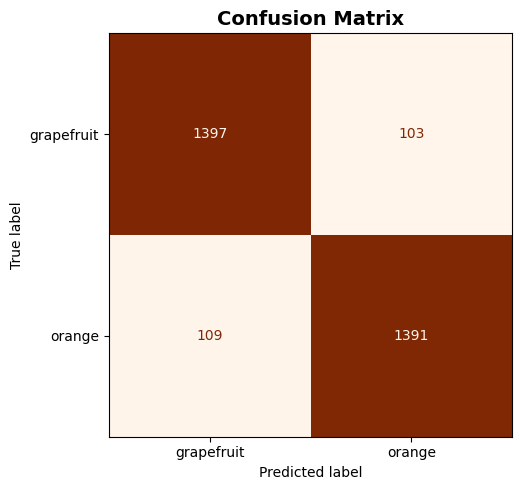

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()